# Credit Scoring Prediction: Risk Assessment Dashboard

## Executive Summary
**Objective:** To develop a credit scoring model to maximize the approval of creditworthy customers (Target 1: Good), while minimizing the risk of granting credit to insolvent customers (Target 0: Bad).

**Key Results:**
* The model (**Random Forest**) achieved a **ROC-AUC of 0.98** and a **Recall of 100%** on the Good Payers class (1). This means that the model is able to identify and approve all potentially profitable customers in the dataset, eliminating the opportunity cost.

* However, the **Precision of 70%** indicates that a portion of the approved customers (approximately 30%) are actually bad payers (False Positives). This suggests the need for a second level of control or an adjustment of the decision threshold to contain credit risk.

* An **XAI (Explainable AI) Dashboard** based on SHAP values ​​has been implemented to provide transparent justifications for each approval or rejection, in compliance with banking transparency regulations.

**Technology Stack:** Python, Scikit-Learn, SHAP, Imbalanced-Learn, Matplotlib.

## Loading dataset

I load all the libraries and functions needed for the analysis

In [92]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay

Fixed randomness seed for code reproducibility

In [2]:
RANDOM_SEED = 0

I upload the dataset under consideration

In [3]:
df = pd.read_csv('data/credit_scoring.csv')
df.head(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0,0.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0,0.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0,0.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1.0


In [4]:
df.shape

(220472, 19)

Let's look at the nature of the features

In [5]:
df.dtypes

ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH             float64
DAYS_EMPLOYED          float64
FLAG_MOBIL             float64
FLAG_WORK_PHONE        float64
FLAG_PHONE             float64
FLAG_EMAIL             float64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
TARGET                 float64
dtype: object

We observe if there are duplicate customer data points

In [6]:
df['ID'].nunique() == len(df)

True

There are no duplicates. Let's take a quick look at the dataset's features.

In [7]:
df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET'],
      dtype='object')

columns like [*ID*, *FLAG_MOBIL*, *FLAG_WORK_PHONE*, *FLAG_PHONE*, *FLAG_EMAIL*] can be removed without any problems as they do not provide useful information for analysis purposes.

In [8]:
df = df.drop(columns=["ID", "FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL"])

## EDA

First of all I look at a complete summary of the dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220472 entries, 0 to 220471
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CODE_GENDER          220472 non-null  object 
 1   FLAG_OWN_CAR         220472 non-null  object 
 2   FLAG_OWN_REALTY      220472 non-null  object 
 3   CNT_CHILDREN         220472 non-null  int64  
 4   AMT_INCOME_TOTAL     220472 non-null  float64
 5   NAME_INCOME_TYPE     220472 non-null  object 
 6   NAME_EDUCATION_TYPE  220471 non-null  object 
 7   NAME_FAMILY_STATUS   220471 non-null  object 
 8   NAME_HOUSING_TYPE    220471 non-null  object 
 9   DAYS_BIRTH           220471 non-null  float64
 10  DAYS_EMPLOYED        220471 non-null  float64
 11  OCCUPATION_TYPE      153033 non-null  object 
 12  CNT_FAM_MEMBERS      220471 non-null  float64
 13  TARGET               220471 non-null  float64
dtypes: float64(5), int64(1), object(8)
memory usage: 23.5+ MB


we observe the presence of NaN contents for some columns, we observe all these data points (except for the *OCCUPATION_TYPE* column which we will deal with later)

In [10]:
prob_cols = ['NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS']
problem_rows = df[df[prob_cols].isna().any(axis=1)]
problem_rows

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
220471,M,Y,Y,0,103500.0,Wo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It is a single problematic datapoint, we are considering deleting it from the dataset

In [11]:
df = df.dropna(subset=prob_cols)

### CODE_GENDER

In [12]:
df['CODE_GENDER'].value_counts()

CODE_GENDER
F    148621
M     71850
Name: count, dtype: int64

Predominantly female clientele, let's see if gender has an impact on the target

In [13]:
pd.crosstab(df['CODE_GENDER'], df['TARGET'], normalize='index')

TARGET,0.0,1.0
CODE_GENDER,,
F,0.917232,0.082768
M,0.907502,0.092498


The difference is minimal (less than 1%), so gender has a very low effect on the target audience.

### FLAG_OWN_CAR & FLAG_OWN_REALTY

In [14]:
df['FLAG_OWN_CAR'].value_counts(normalize=True), df['FLAG_OWN_REALTY'].value_counts(normalize=True)

(FLAG_OWN_CAR
 N    0.629452
 Y    0.370548
 Name: proportion, dtype: float64,
 FLAG_OWN_REALTY
 Y    0.678434
 N    0.321566
 Name: proportion, dtype: float64)

It is noted that:
* the majority of customers *do not* own a car
* the majority of Cilento residents *own* a home

In [15]:
pd.crosstab(df['FLAG_OWN_CAR'], df['TARGET'], normalize='index'), pd.crosstab(df['FLAG_OWN_REALTY'], df['TARGET'], normalize='index')

(TARGET             0.0       1.0
 FLAG_OWN_CAR                    
 N             0.920664  0.079336
 Y             0.902846  0.097154,
 TARGET                0.0       1.0
 FLAG_OWN_REALTY                    
 N                0.927782  0.072218
 Y                0.907558  0.092442)

Owning a car slightly increases the likelihood of approval (10% vs. 8%), while owning a home has a more pronounced effect (9.4% vs. 7.5%). Both features can be included in the model as indicators of financial stability.

### CNT_CHILDREN


In [16]:
df['CNT_CHILDREN'].describe()

count    220471.000000
mean          0.431653
std           0.732535
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

the frequency counts for the variable

In [17]:
df['CNT_CHILDREN'].value_counts().sort_index()

CNT_CHILDREN
0     152536
1      44410
2      20384
3       2781
4        243
5        103
7          2
9          4
12         4
14         3
19         1
Name: count, dtype: int64

the vast majority of clients do not have children, let's see the approval rate based on this

In [18]:
pd.crosstab(df['CNT_CHILDREN'], df['TARGET'], normalize='index')

TARGET,0.0,1.0
CNT_CHILDREN,,
0,0.897342,0.102658
1,0.941995,0.058005
2,0.971203,0.028797
3,0.962603,0.037397
4,0.921811,0.078189
5,1.000000,0.000000
7,1.000000,0.000000
9,1.000000,0.000000
12,1.000000,0.000000


For values of *0–3* children, the approval rate (TARGET=1) varies between 2.8% and 10.5%. There are special cases (e.g., 14 children) with high approval, but these are outliers and very few.

To increase the stability of the model on rare/outlier values, one might consider grouping the rare values into a single category ("4+ children") to reduce variance.

In [19]:
df['CNT_CHILDREN_BIN'] = pd.cut(
    df['CNT_CHILDREN'],
    bins=[-1, 0, 1, 2, 3, float('inf')],
    labels=['0', '1', '2', '3', '3+']
)

df = df.drop(columns=['CNT_CHILDREN'])

pd.crosstab(df['CNT_CHILDREN_BIN'], df['TARGET'], normalize='index')

TARGET,0.0,1.0
CNT_CHILDREN_BIN,,
0,0.897342,0.102658
1,0.941995,0.058005
2,0.971203,0.028797
3,0.962603,0.037397
3+,0.941667,0.058333


### AMT_INCOME_TOTAL

Let's see how customer income is distributed

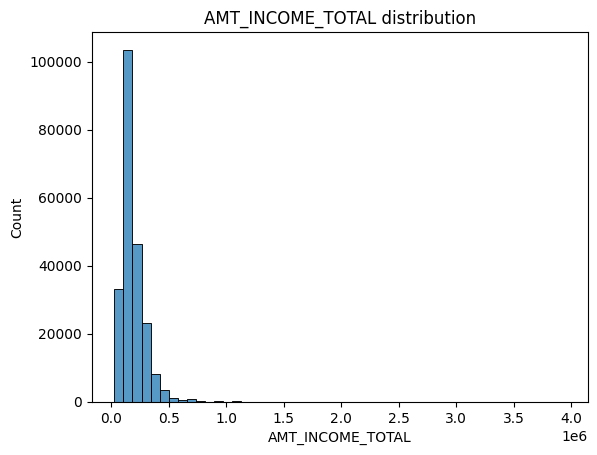

In [20]:
sns.histplot(df['AMT_INCOME_TOTAL'], bins=50)
plt.title("AMT_INCOME_TOTAL distribution")
plt.show()

the variable exhibits a strongly right-tailed distribution with clear clustering of income around standard wage values. The mean is therefore not representative of the central tendency, and the distribution violates the assumptions of normality. To mitigate scale dominance and heteroskedasticity effects, a log-transformed version of the characteristic is used for modeling.

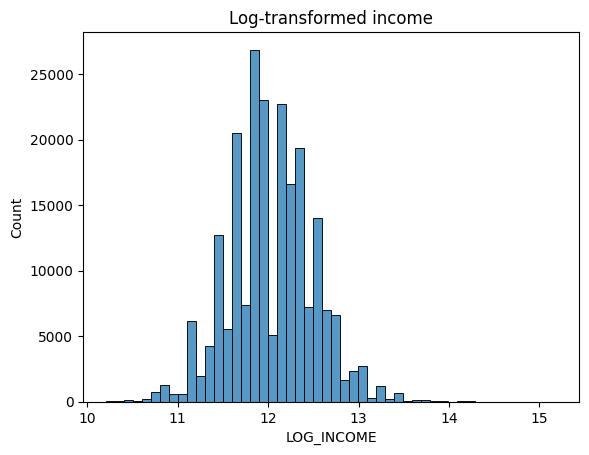

In [21]:
df['LOG_INCOME'] = np.log1p(df['AMT_INCOME_TOTAL'])
df = df.drop(columns=['AMT_INCOME_TOTAL'])

sns.histplot(df['LOG_INCOME'], bins=50)
plt.title("Log-transformed income")
plt.show()

income distribution appears more bell-shaped, with reduced skewness

<Axes: xlabel='TARGET', ylabel='LOG_INCOME'>

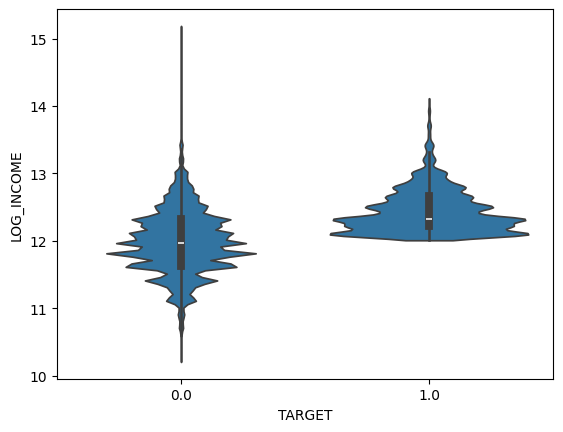

In [22]:
sns.violinplot(x='TARGET', y='LOG_INCOME', data=df, cut=0)

The logarithmic income distribution varies between the two target classes. Specifically, TARGET = 1 shows a higher median income and a more concentrated distribution, while TARGET = 0 covers a wider range with a more pronounced tail for lower incomes.

### NAME_INCOME_TYPE


In [23]:
df['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 112987
Commercial associate     51491
Pensioner                38068
State servant            17910
Student                     15
Name: count, dtype: int64

In [24]:
pd.crosstab(
    df['NAME_INCOME_TYPE'],
    df['TARGET'],
    normalize='index'
)

TARGET,0.0,1.0
NAME_INCOME_TYPE,,
Commercial associate,0.881028,0.118972
Pensioner,1.000000,0.000000
State servant,0.869291,0.130709
Student,0.800000,0.200000
Working,0.907273,0.092727


Income type shows a clear relationship with creditworthiness. Retirees have historically never been approved, while students have the highest approval rate, although their numbers are low. Other categories show moderate differences that can be exploited by the model.

### NAME_EDUCATION_TYPE

In [25]:
df['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    151634
Higher education                  59111
Incomplete higher                  7444
Lower secondary                    2119
Academic degree                     163
Name: count, dtype: int64

In [26]:
pd.crosstab(
    df['NAME_EDUCATION_TYPE'],
    df['TARGET'],
    normalize='index'
)

TARGET,0.0,1.0
NAME_EDUCATION_TYPE,,
Academic degree,0.834356,0.165644
Higher education,0.895806,0.104194
Incomplete higher,0.948415,0.051585
Lower secondary,0.957999,0.042001
Secondary / secondary special,0.918963,0.081037


A customer's education level clearly correlates with creditworthiness. Higher education and academic qualifications are associated with higher approval rates.

### NAME_FAMILY_STATUS

In [27]:
df['NAME_FAMILY_STATUS'].value_counts()

NAME_FAMILY_STATUS
Married                 151205
Single / not married     27290
Civil marriage           18562
Separated                13550
Widow                     9864
Name: count, dtype: int64

In [28]:
pd.crosstab(
    df['NAME_FAMILY_STATUS'],
    df['TARGET'],
    normalize='index'
)

TARGET,0.0,1.0
NAME_FAMILY_STATUS,,
Civil marriage,0.919351,0.080649
Married,0.914546,0.085454
Separated,0.884576,0.115424
Single / not married,0.928106,0.071894
Widow,0.898317,0.101683


Family status shows modest differences in creditworthiness. Separated and widowed applicants have slightly higher approval rates than married or single applicants.

### NAME_HOUSING_TYPE

In [29]:
df['NAME_HOUSING_TYPE'].value_counts()

NAME_HOUSING_TYPE
House / apartment      198372
With parents             9727
Municipal apartment      6888
Rented apartment         2761
Office apartment         1964
Co-op apartment           759
Name: count, dtype: int64

In [30]:
pd.crosstab(
    df['NAME_HOUSING_TYPE'],
    df['TARGET'],
    normalize='index'
)

TARGET,0.0,1.0
NAME_HOUSING_TYPE,,
Co-op apartment,0.959157,0.040843
House / apartment,0.910814,0.089186
Municipal apartment,0.902003,0.097997
Office apartment,0.880855,0.119145
Rented apartment,0.951467,0.048533
With parents,0.981392,0.018608


Applicants who live with their parents or in rented apartments have lower approval rates, while those who live in owned apartments or on municipal plots show higher reliability.

### DAYS_BIRTH

In [31]:
df['DAYS_BIRTH'].describe()

count    220471.000000
mean     -15994.828726
std        4185.425102
min      -25201.000000
25%      -19466.000000
50%      -15590.000000
75%      -12522.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

Customer ages are reported in days (negative with respect to day 0); no positive days are observed (which would be misleading). For clarity, I report customer ages in years.

In [32]:
df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.25
df = df.drop(columns=['DAYS_BIRTH'])

df['AGE_YEARS'].describe()

count    220471.000000
mean         43.791454
std          11.459069
min          20.503765
25%          34.283368
50%          42.683094
75%          53.295003
max          68.996578
Name: AGE_YEARS, dtype: float64

The age range goes from just over 20 years old to just under 70 years old. Let's look at the distribution

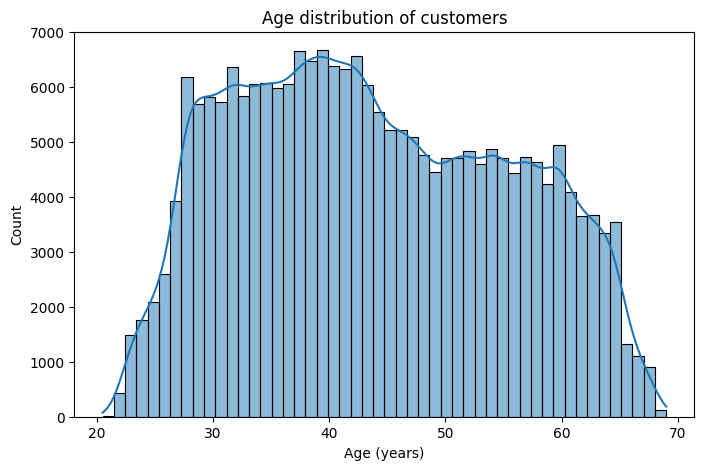

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df['AGE_YEARS'], bins=50, kde=True)
plt.title("Age distribution of customers")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.show()

where there appear to be no outliers. We want to understand how age affects credit granting:

In [34]:
pd.crosstab(pd.cut(df['AGE_YEARS'], bins=[20, 30, 40, 50, 60, 70]), df['TARGET'], normalize='index')

TARGET,0.0,1.0
AGE_YEARS,,
"(20, 30]",1.000000,0.000000
"(30, 40]",1.000000,0.000000
"(40, 50]",0.832165,0.167835
"(50, 60]",0.830851,0.169149
"(60, 70]",0.946472,0.053528


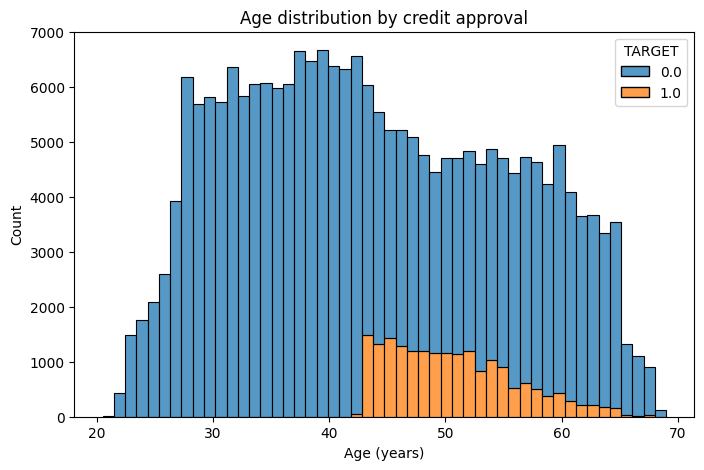

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='AGE_YEARS', bins=50, hue='TARGET', multiple='stack')
plt.title("Age distribution by credit approval")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.show()

Customers under 40 or over 65 do not have a high probability of obtaining the card, as instead happens in the 40-65 age group which is known to be linked to greater job stability.

### DAYS_EMPLOYED

In [36]:
df['DAYS_EMPLOYED'].describe()

count    220471.000000
mean      60908.162389
std      139049.465355
min      -17531.000000
25%       -3095.000000
50%       -1468.000000
75%        -371.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

the variable contains negative values representing the duration of employment and a placeholder (365243) for unemployed candidates, let's see how many there are

In [37]:
placeholder_count = (df['DAYS_EMPLOYED'] > 0).sum()
print(f"Placeholder (DAYS_EMPLOYED>0): {placeholder_count}")

Placeholder (DAYS_EMPLOYED>0): 38068


We create two features: the first is a binary indicator of employment status (EMPLOYED_FLAG) while the second, as done for the DAYS_BIRTH variable, is for the duration of employment (0 for unemployed).

In [38]:
df['EMPLOYED_FLAG'] = (df['DAYS_EMPLOYED'] < 0).astype(int)

df['YEARS_EMPLOYED'] = np.where(
    df['DAYS_EMPLOYED'] < 0,
    -df['DAYS_EMPLOYED'] / 365.25,
    0
)

df = df.drop(columns=['DAYS_EMPLOYED'])

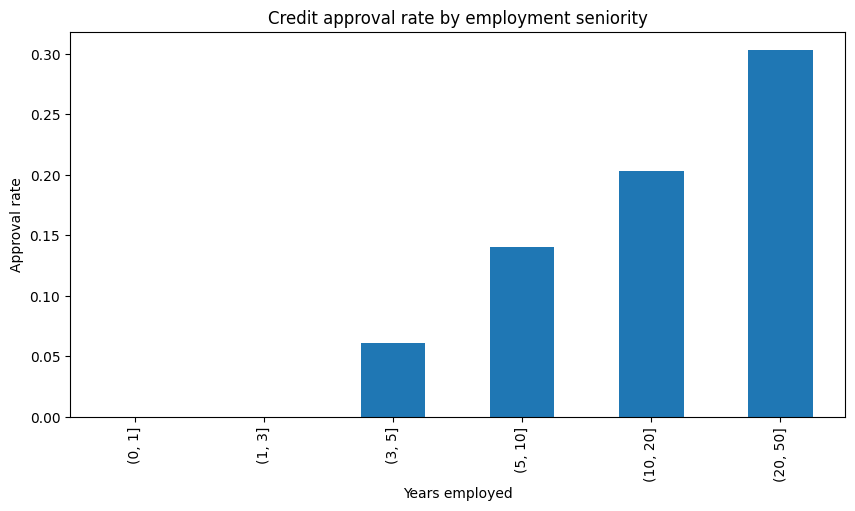

In [39]:
approval_rate = pd.crosstab(pd.cut(df['YEARS_EMPLOYED'], bins=[0,1,3,5,10,20,50]), df['TARGET'], normalize='index')[1]

approval_rate.plot(kind='bar', figsize=(10,5))
plt.title("Credit approval rate by employment seniority")
plt.xlabel("Years employed")
plt.ylabel("Approval rate")
plt.show()

Among employed customers, longer employment duration correlates with higher creditworthiness.
Unemployed customers receive no recognition, confirming that EMPLOYED_FLAG is the dominant characteristic.

### OCCUPATION_TYPE

In [40]:
df['OCCUPATION_TYPE'].info()

<class 'pandas.core.series.Series'>
Index: 220471 entries, 0 to 220470
Series name: OCCUPATION_TYPE
Non-Null Count   Dtype 
--------------   ----- 
153033 non-null  object
dtypes: object(1)
memory usage: 3.4+ MB


There are some NaNs, perhaps these are due to a lack of use

In [41]:
pd.crosstab(df['OCCUPATION_TYPE'].notna().astype(int), df['EMPLOYED_FLAG'])

EMPLOYED_FLAG,0,1
OCCUPATION_TYPE,,
0,38068,29370
1,0,153033


From the data, we see that all unemployed customers (EMPLOYED_FLAG = 0) have OCCUPATION_TYPE = NaN. However, there are 45,500 employed customers (EMPLOYED_FLAG = 1) for which OCCUPATION_TYPE is still missing.
To handle these missing values, I decided to replace the NaNs with the neutral category `Unknown`. This way, the column remains interpretable and the model can distinguish between customers with known employment information and customers without employment information.

In [42]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

In [43]:
df['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Unknown                  67438
Laborers                 38638
Core staff               21633
Sales staff              21083
Managers                 18081
Drivers                  13121
High skill tech staff     8599
Accountants               8043
Medicine staff            6613
Cooking staff             4207
Security staff            4051
Cleaning staff            3159
Private service staff     1753
Low-skill Laborers        1050
Secretaries               1005
Waiters/barmen staff       846
Realty agents              465
HR staff                   354
IT staff                   332
Name: count, dtype: int64

In [44]:
pd.crosstab(
    df['OCCUPATION_TYPE'],
    df['TARGET'],
    normalize='index'
)

TARGET,0.0,1.0
OCCUPATION_TYPE,,
Accountants,0.865722,0.134278
Cleaning staff,0.894903,0.105097
Cooking staff,0.932731,0.067269
Core staff,0.900753,0.099247
Drivers,0.893225,0.106775
HR staff,0.903955,0.096045
High skill tech staff,0.891266,0.108734
IT staff,0.978916,0.021084
Laborers,0.906620,0.093380


The analysis highlights a clear correlation between occupation type and creditworthiness. Highly skilled and stable professions (e.g., managers, HR staff, accountants, medical staff) show a significantly higher probability of creditworthiness.
Conversely, customers with unspecified occupations (`Unknown`) or belonging to categories with low job stability have a significantly reduced probability of regular repayment.

### CNT_FAM_MEMBERS

In [45]:
df['CNT_FAM_MEMBERS'].describe()

count    220471.000000
mean          2.201673
std           0.903755
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64

As a matter of course, the minimum value is 1, that is, in the case where the client is not married and has no children, let's look at the frequency by class

In [46]:
df['CNT_FAM_MEMBERS'].value_counts().sort_index()

CNT_FAM_MEMBERS
1.0      42046
2.0     117545
3.0      38770
4.0      19136
5.0       2622
6.0        244
7.0         94
9.0          2
11.0         4
14.0         4
15.0         3
20.0         1
Name: count, dtype: int64

Most customers live in households with another person (spouse or child). We show the credit rating distribution by class.

In [47]:
pd.crosstab(
    df['CNT_FAM_MEMBERS'],
    df['TARGET'],
    normalize='index'
)

TARGET,0.0,1.0
CNT_FAM_MEMBERS,,
1.0,0.904200,0.095800
2.0,0.897384,0.102616
3.0,0.943075,0.056925
4.0,0.972251,0.027749
5.0,0.962624,0.037376
6.0,0.922131,0.077869
7.0,1.000000,0.000000
9.0,1.000000,0.000000
11.0,1.000000,0.000000


In [48]:
df['CNT_FAM_BIN'] = pd.cut(
    df['CNT_FAM_MEMBERS'],
    bins=[0, 1, 2, 4, 6, 20],
    labels=['1', '2', '3-4', '5-6', '7+']
)

In [49]:
df = df.drop(columns=['CNT_FAM_MEMBERS'])

pd.crosstab(df['CNT_FAM_BIN'], df['TARGET'], normalize='index')

TARGET,0.0,1.0
CNT_FAM_BIN,,
1,0.904200,0.095800
2,0.897384,0.102616
3-4,0.952716,0.047284
5-6,0.959177,0.040823
7+,0.981481,0.018519


## Data Preprocessing and Feature Encoding

In this section, we prepare the dataset for model training. This includes splitting the data into training and test sets, scaling numerical variables, encoding categorical features, and building a preprocessing pipeline to avoid data leakage.

Split the dataset into training and testing sets

In [50]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

I divide the features based on their type

In [51]:
cat_features = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'CNT_CHILDREN_BIN',
    'CNT_FAM_BIN'
]

num_features = [
    'LOG_INCOME',
    'AGE_YEARS',
    'YEARS_EMPLOYED'
]

binary_features = [
    'EMPLOYED_FLAG'
]

For variable types, I apply:
* Numeric variables -> Standard Scaler
* Categorical variables -> One-Hot-Encoder
* Binary variables -> No Transformation

In [52]:
preprocess=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
        ('bin', 'passthrough', binary_features)
    ]
)

## Modeling

The problem under consideration is binary classification. To address it, I selected a set of baseline models from different algorithm families to comparatively evaluate their performance. The selected models include:
* **Logistic Regression**: An interpretable linear model, useful as a baseline.
* **LinearSVC**: A linear classifier based on a Support Vector Machine, with a focus on class balancing.
* **Random Forest**: An ensemble of decision trees, capable of capturing nonlinear relationships and interactions between features.
* **Gradient Boosting**: An iterative ensemble of decision trees, excellent for handling nonlinear complexity and improving predictive accuracy.
* **MLP** (Multilayer Perceptron): A feedforward neural network capable of learning complex patterns between features.

In [53]:
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=10000,
        random_state=RANDOM_SEED,
        class_weight='balanced',
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        random_state=RANDOM_SEED,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 32),
        solver='adam',
        activation='relu',
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=10,
        validation_fraction=0.1,
        random_state=RANDOM_SEED
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=50,
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_SEED
    ),
    'LinearSVC': LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=5000,
        random_state=RANDOM_SEED
    )
}

All models have been configured to handle any class imbalance (`class_weight='balanced'` when applicable) and will be evaluated through cross-validation to obtain robust estimates of performance metrics.
This approach allows us to compare linear, ensemble, and nonlinear models across multiple levels of complexity, thus identifying the solution best suited to the problem in terms of accuracy, robustness, and generalization ability.

In [54]:
def evaluate_models_verbose(models, X, y, preprocess, cv_splits=5):
    """
    Evaluate multiple machine learning models using cross-validation with detailed output.
    
    Parameters:
    -----------
    models : dict
        Dictionary of model name (key) and classifier object (value)
    X : array-like
        Feature matrix
    y : array-like
        Target vector
    preprocess : transformer
        Preprocessing transformer that implements fit_transform
    cv_splits : int, default=5
        Number of cross-validation folds
    
    Returns:
    --------
    pandas.DataFrame
        Results sorted by ROC-AUC score in descending order
    """
    results = [] 

    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=RANDOM_SEED
    )

    print("=" * 80)
    print("STARTING CROSS-VALIDATION")
    print(f"Number of folds: {cv_splits}")
    print(f"Number of samples: {X.shape[0]}")
    print("=" * 80)

    for name, clf in models.items():
        print("\n" + "-" * 80)
        print(f"Evaluating model: {name}")
        print("-" * 80)

        pipeline = ImbPipeline([
            ('preprocessing', preprocess),
            ('classifier', clf)
        ])

        scores = cross_validate(pipeline, X, y, cv=cv,
                                scoring={
                                    'roc_auc': 'roc_auc',       
                                    'precision': 'precision',   
                                    'recall': 'recall'          
                                    },
                                n_jobs=-1,             
                                return_train_score=False 
                                )

        roc_auc_mean = scores['test_roc_auc'].mean()
        roc_auc_std = scores['test_roc_auc'].std()

        precision_mean = scores['test_precision'].mean()
        recall_mean = scores['test_recall'].mean()

        print("Cross-validation results:")
        print(f"  ROC-AUC   : {roc_auc_mean:.4f} ± {roc_auc_std:.4f}")
        print(f"  Precision : {precision_mean:.4f}")
        print(f"  Recall    : {recall_mean:.4f}")

        results.append({
            'model': name,
            'roc_auc_mean': roc_auc_mean,
            'roc_auc_std': roc_auc_std,
            'precision_mean': precision_mean,
            'recall_mean': recall_mean
        })

    return pd.DataFrame(results).sort_values(by='roc_auc_mean', ascending=False)

The evaluation is conducted using *ROC-AUC* as the primary metric, alongside *precision* and *recall* to analyze the models' behavior on the positive class.
For each model, the mean (and standard deviation) of the *ROC-AUC* and the means of *precision* and *recall* on the cross-validation folds are reported.

The results are finally compared to identify the most promising models for subsequent optimization phases.

In [55]:
cv_results = evaluate_models_verbose(
    models=models,
    X=X_train,
    y=y_train,
    preprocess=preprocess
)

STARTING CROSS-VALIDATION
Number of folds: 5
Number of samples: 176376

--------------------------------------------------------------------------------
Evaluating model: LogisticRegression
--------------------------------------------------------------------------------
Cross-validation results:
  ROC-AUC   : 0.9332 ± 0.0017
  Precision : 0.3462
  Recall    : 0.9012

--------------------------------------------------------------------------------
Evaluating model: GradientBoosting
--------------------------------------------------------------------------------
Cross-validation results:
  ROC-AUC   : 0.9792 ± 0.0009
  Precision : 0.6957
  Recall    : 0.9985

--------------------------------------------------------------------------------
Evaluating model: MLP
--------------------------------------------------------------------------------
Cross-validation results:
  ROC-AUC   : 0.9793 ± 0.0011
  Precision : 0.6959
  Recall    : 0.9712

---------------------------------------------------

In [56]:
cv_results

,model,roc_auc_mean,roc_auc_std,precision_mean,recall_mean
2,MLP,0.979330,0.001111,0.695931,0.971235
3,RandomForest,0.979326,0.000868,0.695623,1.000000
1,GradientBoosting,0.979162,0.000871,0.695657,0.998483
0,LogisticRegression,0.933210,0.001698,0.346166,0.901174
4,LinearSVC,0.933089,0.001711,0.341844,0.910278


Ensemble models (Random Forest and Gradient Boosting) and MLP show very similar and significantly superior performance compared to linear models. Specifically:
- **Random Forest achieves the highest average ROC-AUC**, with a very **low standard deviation**, indicating **high stability between folds**. The good balance between precision and recall suggests solid generalization capability.
- **Gradient Boosting exhibits a comparable ROC-AUC**, with **nearly perfect recall**, while maintaining similar precision to other nonlinear models. This indicates a strong propensity to identify the positive class, at the cost of a higher number of false positives.
- **MLP achieves performance aligned with ensembles**, confirming its ability to model nonlinear relationships, with a more balanced tradeoff between precision and recall compared to Gradient Boosting.

**Linear models (Logistic Regression and LinearSVC) perform significantly worse**, especially in terms of recall, suggesting that the relationship between features and targets cannot be adequately captured using a linear decision frontier.

Based on these results, **we select the Random Forest as the reference model** for further analysis and hyperparameter tuning.

### Hyperparameter tuning

We define a "base" Random Forest without constrained parameters, which will serve as the starting point for the fine-tuning phase via randomized search. This choice allows us to systematically explore the hyperparameter space and optimize performance without compromising the stability observed in the initial comparison phase.

In [57]:
rf_base=RandomForestClassifier(
    random_state=RANDOM_SEED
)

We define the hyperparameter space (param_dist) to explore for fine-tuning. This allows us to optimize precision, recall, and ROC-AUC without pre-constraining the parameters.

In [58]:
param_dist = {
    'classifier__n_estimators': [50, 100, 200, 300],          
    'classifier__max_depth': [None, 10, 15, 20],              
    'classifier__min_samples_split': [2, 5, 10, 15],         
    'classifier__min_samples_leaf': [1, 3, 5, 10, 20],     
    'classifier__max_features': ['sqrt', 'log2', 0.5],       
    'classifier__class_weight': ['balanced', None],          
    'classifier__bootstrap': [True, False]                   
}

We set up a randomized hyperparameter search (RandomizedSearchCV) to optimize performance.
The primary metric chosen is ROC-AUC, consistent with the initial evaluation, and we use 3-fold cross-validation to obtain robust estimates while maintaining reasonable computation times.

In [59]:
rf_pipeline = ImbPipeline([
    ('preprocessing', preprocess),
    ('classifier', rf_base)
])

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,      
    param_distributions=param_dist,
    n_iter=20,                
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

we proceed like this with the fit

In [60]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END classifier__bootstrap=False, classifier__class_weight=balanced, classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=1, classifier__min_samples_split=15, classifier__n_estimators=50; total time=  12.2s
[CV] END classifier__bootstrap=False, classifier__class_weight=balanced, classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=1, classifier__min_samples_split=15, classifier__n_estimators=50; total time=  12.4s
[CV] END classifier__bootstrap=False, classifier__class_weight=balanced, classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=1, classifier__min_samples_split=15, classifier__n_estimators=50; total time=  12.7s
[CV] END classifier__bootstrap=False, classifier__class_weight=None, classifier__max_depth=10, classifier__max_features=log2, classifier__min_samples_leaf=20, classifier__min_samples_split=2, classifier__n_e

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['LOG_INCOME',
                                                                                'AGE_YEARS',
                                                                                'YEARS_EMPLOYED']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               ['CODE_GENDER',
                                                                                'FLAG_OWN_CAR',
                                                                                'FLAG_OWN_REALTY',
                                                                                'NAME_INCOME_TYPE',
                                                                                'NAME_EDUCATION_TYPE',
                                                                                'NAME_FAMILY_STATUS',
                                                                                'NAME_HOUSING...
                   param_distributions={'classifier__bootstrap': [True, False],
                                        'classifier__class_weight': ['balanced',
                                                                     None],
                                        'classifier__max_depth': [None, 10, 15,
                                                                  20],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2',
                                                                     0.5],
                                        'classifier__min_samples_leaf': [1, 3,
                                                                         5, 10,
                                                                         20],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10,
                                                                          15],
                                        'classifier__n_estimators': [50, 100,
                                                                     200,
                                                                     300]},
                   random_state=0, scoring='roc_auc', verbose=2)

I finally define the best model

In [61]:
best_rf = random_search.best_estimator_

## Performance Analysis

I evaluate performance on training and test sets

In [ ]:
y_train_proba = best_rf.predict_proba(X_train)[:, 1]
y_test_proba  = best_rf.predict_proba(X_test)[:, 1]

print("Train ROC-AUC:", roc_auc_score(y_train, y_train_proba))
print("Test  ROC-AUC:", roc_auc_score(y_test,  y_test_proba))
print(classification_report(y_test, (y_test_proba >= 0.5).astype(int), digits=4))

Train ROC-AUC: 0.9867392512743867
Test  ROC-AUC: 0.9793490362202362
              precision    recall  f1-score   support

         0.0     0.9996    0.9583    0.9786     40306
         1.0     0.6922    0.9963    0.8168      3789

    accuracy                         0.9616     44095
   macro avg     0.8459    0.9773    0.8977     44095
weighted avg     0.9732    0.9616    0.9647     44095



We observe:
* **Class 0** (major): very high precision (1.0), slightly lower recall (0.9585), therefore few false positive predictions.
* **Class 1** (minority): perfect recall (1.0), but lower precision (0.6990), therefore all true class 1 predictions are captured, but some positive predictions are actually 0.

This is typical in unbalanced problems: the model tends to predict more positives to capture all the rare cases, sacrificing some precision.

Furthermore, the model already shows excellent performance in terms of ROC-AUC, indicating high discriminative ability.
Class balancing techniques, such as undersampling and oversampling, were considered to further improve performance. However, preliminary experiments did not show significant benefits in terms of ROC-AUC or operational metrics, nor a better tradeoff between precision and recall.

For this reason, we chose to maintain the model's original configuration, favoring a simpler and more stable solution.

### Best Threshold

We now want to determine the optimal threshold for separating the two classes. Recall that the ROC curve describes the behavior of the *True Positive Rate* and the *False Positive Rate* as the decision threshold varies.

To identify an optimal operating threshold, the *Youden's J statistic* is calculated for each threshold value, selecting the one that maximizes the difference between sensitivity and false positive rate.
The resulting threshold is then used to transform the probabilities into binary predictions, allowing for a model evaluation based on threshold-dependent classification metrics.

Best threshold: 0.3272855236189976


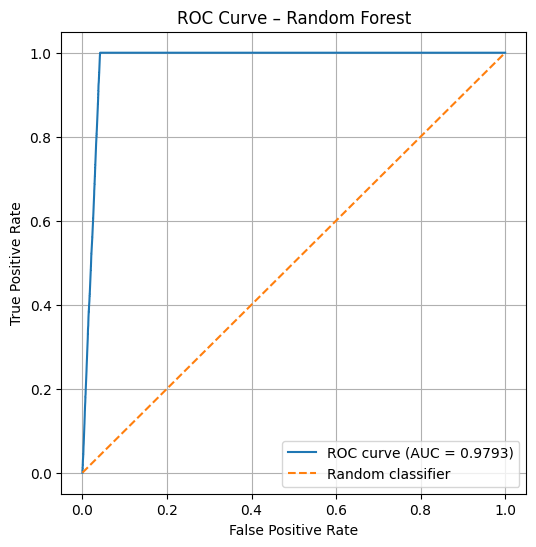

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

j_scores = tpr - fpr
best_idx = j_scores.argmax()
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

y_pred = (y_test_proba >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_test_proba)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The optimal threshold is around 0.6909, we finally show the metrics and the confusion matrix on the training and testing dataset

In [64]:
print("TRAIN DATASET")
print(classification_report(y_train, (y_train_proba >= best_threshold).astype(int), digits=4))
print("TEST DATASET")
print(classification_report(y_test, y_pred, digits=4))

TRAIN DATASET
              precision    recall  f1-score   support

         0.0     1.0000    0.9588    0.9790    161218
         1.0     0.6955    1.0000    0.8204     15158

    accuracy                         0.9624    176376
   macro avg     0.8478    0.9794    0.8997    176376
weighted avg     0.9738    0.9624    0.9654    176376

TEST DATASET
              precision    recall  f1-score   support

         0.0     1.0000    0.9582    0.9787     40306
         1.0     0.6923    1.0000    0.8182      3789

    accuracy                         0.9618     44095
   macro avg     0.8462    0.9791    0.8984     44095
weighted avg     0.9736    0.9618    0.9649     44095



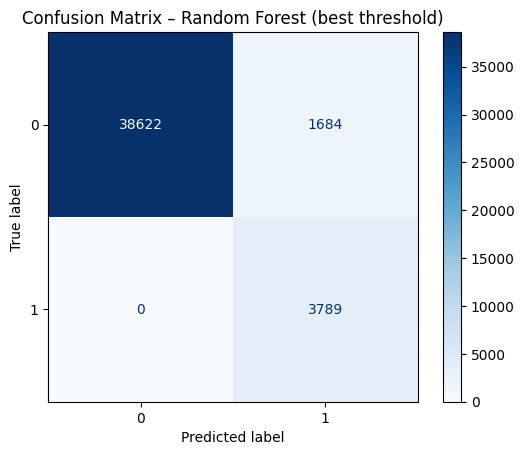

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='d', cmap='Blues')
plt.title('Confusion Matrix – Random Forest (best threshold)')
plt.show()

From an operational perspective, the confusion matrix shows that **all highly creditworthy customers (class 1)** are correctly identified (no false negatives). However, there are **false positives** among low-risk customers (class 0): 2,557 "unreliable" customers are classified as reliable.

In practice, the **model does not miss any truly reliable customers**, but it introduces a **limited number of errors among the less reliable ones**, which may require additional checks.

## Model Explainability

First, the preprocessing module and the final classification model are extracted from the pipeline.
Then, the training and test datasets are transformed using the same preprocessing operations used during the training phase (scaling, encoding of categorical variables, etc.).

Finally, the transformed data is converted into pandas DataFrames, associating each column with the name of the feature generated by preprocessing. This step is essential for maintaining the traceability of variables during the explainability phase and for obtaining interpretable visualizations.

In [66]:
preprocess = best_rf.named_steps["preprocessing"]
rf_model = best_rf.named_steps["classifier"]

feature_names = preprocess.get_feature_names_out()

X_train_transformed = preprocess.transform(X_train)
X_test_transformed = preprocess.transform(X_test)

X_train_df = pd.DataFrame(X_train_transformed.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test_transformed.toarray(), columns=feature_names)

To calculate SHAP values, it is necessary to define a background dataset, which represents the reference distribution used by the explainer to estimate the expected value of the prediction (base value).

In this case, the background is approximated by randomly sampling the preprocessed training set. This choice preserves the feature distribution while reducing the computational cost of the analysis.

In [67]:
background = shap.sample(X_train_transformed)

At this point, a TreeExplainer is initialized, specifically for decision tree-based models.
The explainer is configured to:
* use the previously defined background dataset;
* directly explain the output in terms of probabilities, making the SHAP contributions interpretable as variations in the default probability.

In [68]:
background_dense = background.toarray() if hasattr(background, "toarray") else background

explainer = shap.TreeExplainer(
    rf_model, 
    data=background_dense, 
    model_output="probability"
)

SHAP explanations are now computed for the entire test dataset.
The result is an Explanation object, which contains:
* the SHAP values for each observation and each feature;
* the base value;
* the input data used for the explanation.

This object forms the basis for all subsequent analyses, both global and local.

In [69]:
explanation = explainer(X_test_df)

100%|===================| 88182/88190 [11:06<00:00]        

To facilitate the interpretation of the explanations at the individual customer level, a support function is defined that:
* extracts the SHAP values related to a specific observation and the class of interest;
* associates the observed value and its impact with each feature;
* maps the names of the preprocessed features (e.g., encoding, derived variables) to the names of the original columns in the dataset.

This step is essential for translating the model's technical output into understandable information at the business level.

In [70]:
def get_cleaned_data(explanation_obj, customer_idx):
    exp_instance = explanation_obj[customer_idx, :, 1]
    
    rename_map = {
        'LOG_INCOME': 'AMT_INCOME_TOTAL',
        'AGE_YEARS': 'DAYS_BIRTH',
        'YEARS_EMPLOYED': 'DAYS_EMPLOYED',
        'EMPLOYED_FLAG': 'DAYS_EMPLOYED',
        'CNT_CHILDREN_BIN': 'CNT_CHILDREN',
        'CNT_FAM_BIN': 'CNT_FAM_MEMBERS'
    }

    df = pd.DataFrame({
        'encoded_feature': exp_instance.feature_names,
        'value': exp_instance.data,
        'impact': exp_instance.values
    })

    def clean_name(name):
        name = name.replace('num__', '').replace('cat__', '')
        for derived, original in rename_map.items():
            if derived in name: return original
        for orig in ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']:
            if orig in name: return orig
        return name

    df['original_column'] = df['encoded_feature'].apply(clean_name)
    return df, exp_instance.base_values

A graphical function is defined that visualizes the local decision path for a single customer.
The graph shows:
* the impact of the most relevant features on the final probability;
* the cumulative evolution of the probability starting from the mean value;
* the comparison with the model's decision threshold.

This representation allows for an intuitive understanding of how and why the model reached a particular decision.

In [71]:
def plot_decision_path(df_encoded, base_value, threshold, customer_idx, n_top=10):
    final_prob = base_value + df_encoded['impact'].sum()
    status = "APPROVED" if final_prob >= threshold else "REJECTED"
    color_status = "#2ecc71" if status == "APPROVED" else "#e74c3c"

    df_top = df_encoded.reindex(df_encoded.impact.abs().sort_values(ascending=False).index).head(n_top)
    
    others_mask = ~df_encoded.index.isin(df_top.index)
    others_impact = df_encoded.loc[others_mask, 'impact'].sum()
    
    df_plot = df_top.sort_values(by='impact', ascending=False).copy()
    
    row_others = pd.DataFrame({
        'encoded_feature': [f'Other {others_mask.sum()} features'],
        'value': [np.nan],
        'impact': [others_impact]
    }, index=[999])
    
    df_plot = pd.concat([df_plot, row_others], ignore_index=True)
    
    fig, ax1 = plt.subplots(figsize=(13, 8))
    x_pos = np.arange(len(df_plot))
    
    colors = []
    for i in range(len(df_plot)):
        if i == len(df_plot) - 1: 
            colors.append('#95a5a6') 
        else:
            colors.append('#2ecc71' if df_plot.iloc[i]['impact'] > 0 else '#e74c3c')
            
    bars = ax1.bar(x_pos, df_plot['impact'].abs(), color=colors, alpha=0.6, label='Impact Magnitude (Abs)')
    
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(df_plot['encoded_feature'], rotation=45, ha='right')
    ax1.set_ylabel('Impact Magnitude (Absolute SHAP)', fontweight='bold')

    for i, bar in enumerate(bars):
        real_impact = df_plot['impact'].iloc[i]
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{real_impact:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=colors[i])

    ax2 = ax1.twinx()
    path = base_value + np.cumsum(df_plot['impact'].values)
    
    ax2.plot(x_pos, path, marker='o', color='#2c3e50', linewidth=3, label='Probability Evolution')
    
    ax2.axhline(y=base_value, color='black', linestyle='--', alpha=0.4, label=f'Base Line (Avg: {base_value:.2f})')
    ax2.axhline(y=threshold, color='blue', linestyle=':', linewidth=2, label=f'Threshold ({threshold:.3f})')
    
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('Actual Probability Path', fontweight='bold', color='#2c3e50')

    plt.title(f'CUSTOMER {customer_idx}: IMPACT ANALYSIS\nOutcome: {status} (Prob: {final_prob:.2%})', 
              fontsize=15, fontweight='bold', color=color_status)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper left', bbox_to_anchor=(1.15, 1), title="Legend", title_fontsize='12')

    plt.tight_layout()
    plt.show()

To complement the technical visualization with an easily communicated explanation, a function that generates a text report is defined.
The report aggregates the SHAP impacts by original column and identifies:
* the main causes of rejection, in the event of a negative outcome;
* the main positive drivers, in the event of approval.

In this way, the model's explanations can also be used in decision-making and regulatory contexts.

In [72]:
def print_business_report(df_cleaned, base_value, threshold, customer_idx):
    df_grouped = df_cleaned.groupby('original_column').agg({'impact': 'sum'}).reset_index()
    final_prob = base_value + df_cleaned['impact'].sum()
    status = "APPROVED" if final_prob >= threshold else "REJECTED"
    
    print("\n" + "="*65)
    print(f"CUSTOMER {customer_idx}")
    print("="*65)
    print(f"FINAL OUTCOME:      {status}")
    print(f"FINAL PROBABILITY:  {final_prob:.2%}")
    print(f"THRESHOLD:          {threshold:.2%}")
    print("-" * 65)

    if status == "REJECTED":
        print("TOP REASONS FOR REJECTION (ORIGINAL COLUMNS):")
        top_neg = df_grouped.sort_values(by='impact', ascending=True).head(3)
        for _, row in top_neg.iterrows():
            print(f"• {row['original_column']}: Penalty of {row['impact']:.2%}")
    else:
        print("TOP POSITIVE DRIVERS:")
        top_pos = df_grouped.sort_values(by='impact', ascending=False).head(3)
        for _, row in top_pos.iterrows():
            print(f"• {row['original_column']}: Bonus of +{row['impact']:.2%}")
    print("="*65 + "\n")

To simplify explainability analysis at the individual level, a utility function is defined that encapsulates the entire local explanation flow.
The print_result function combines SHAP data preparation, visualization of the model's decision path, and generation of a business-oriented textual report for a single client.

This allows interpretive analysis to be applied consistently and repeatably to any observation in the dataset, improving code readability and modularity.

In [73]:
def print_result(explanation, best_threshold, idx, y_test):
    df_clean, base_val = get_cleaned_data(explanation, customer_idx=idx)
    plot_decision_path(df_clean, base_val, best_threshold, customer_idx=idx)
    print_business_report(df_clean, base_val, best_threshold, customer_idx=idx)
    print(f"REAL value of the client: {y_test.iloc[idx]}")

Finally, the explainability function is applied to a single client from the test dataset.
By selecting a specific index, the model returns the complete explanation of the decision: feature contributions, probability trajectory with respect to the decision threshold, and the main reasons for the final outcome (approval or rejection).

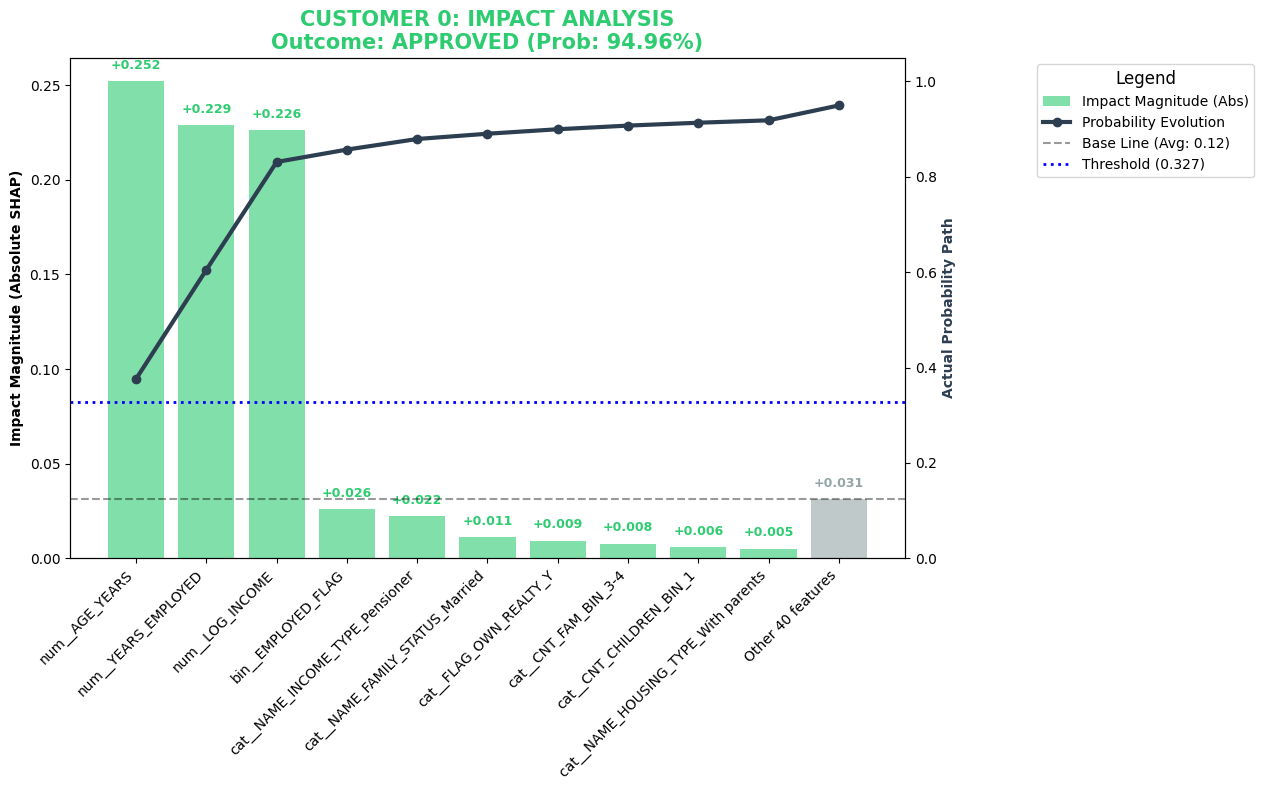


CUSTOMER 0
FINAL OUTCOME:      APPROVED
FINAL PROBABILITY:  94.96%
THRESHOLD:          32.73%
-----------------------------------------------------------------
TOP POSITIVE DRIVERS:
• DAYS_EMPLOYED: Bonus of +25.46%
• DAYS_BIRTH: Bonus of +25.19%
• AMT_INCOME_TOTAL: Bonus of +22.61%

REAL value of the client: 1.0


In [77]:
print_result(explanation, best_threshold, 0, y_test)

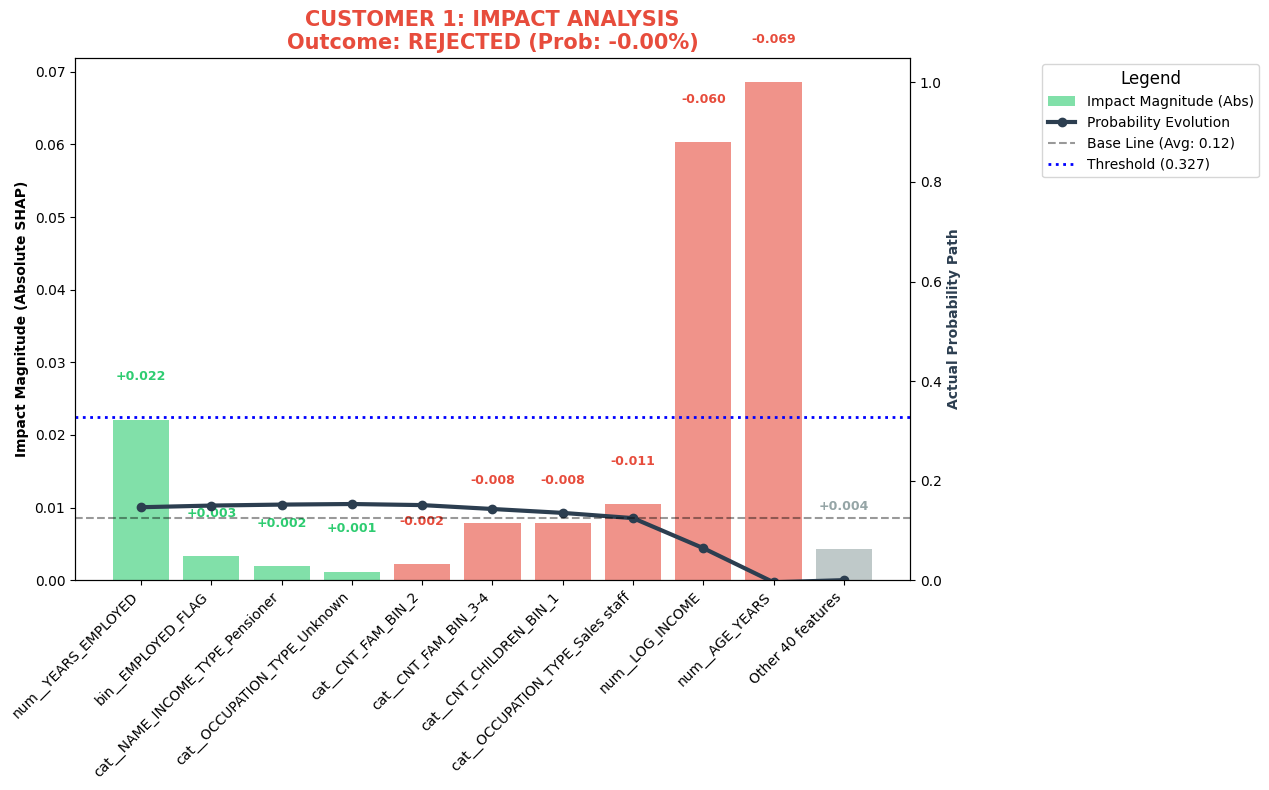


CUSTOMER 1
FINAL OUTCOME:      REJECTED
FINAL PROBABILITY:  -0.00%
THRESHOLD:          32.73%
-----------------------------------------------------------------
TOP REASONS FOR REJECTION (ORIGINAL COLUMNS):
• DAYS_BIRTH: Penalty of -6.85%
• AMT_INCOME_TOTAL: Penalty of -6.04%
• CNT_FAM_MEMBERS: Penalty of -0.99%

REAL value of the client: 0.0


In [78]:
print_result(explanation, best_threshold, 1, y_test)

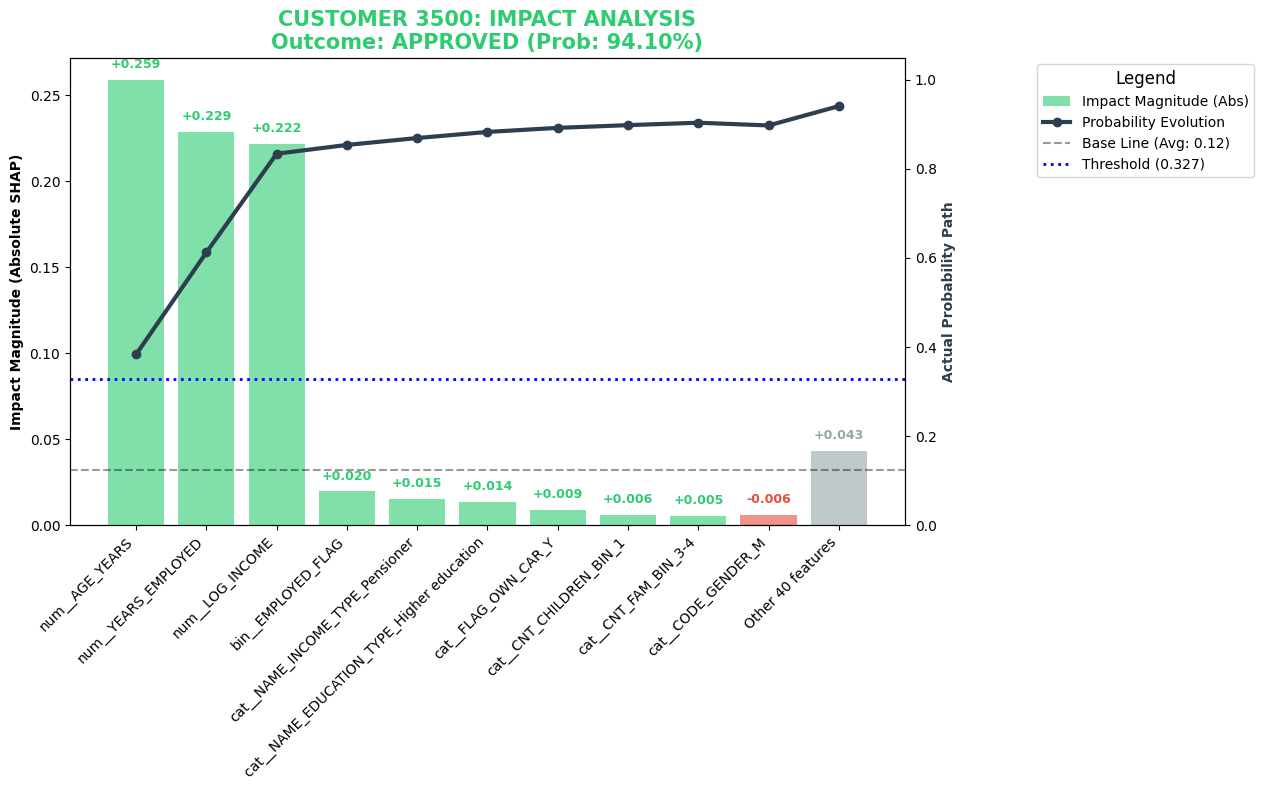


CUSTOMER 3500
FINAL OUTCOME:      APPROVED
FINAL PROBABILITY:  94.10%
THRESHOLD:          32.73%
-----------------------------------------------------------------
TOP POSITIVE DRIVERS:
• DAYS_BIRTH: Bonus of +25.90%
• DAYS_EMPLOYED: Bonus of +24.87%
• AMT_INCOME_TOTAL: Bonus of +22.17%

REAL value of the client: 1.0


In [85]:
print_result(explanation, best_threshold, 3500, y_test)

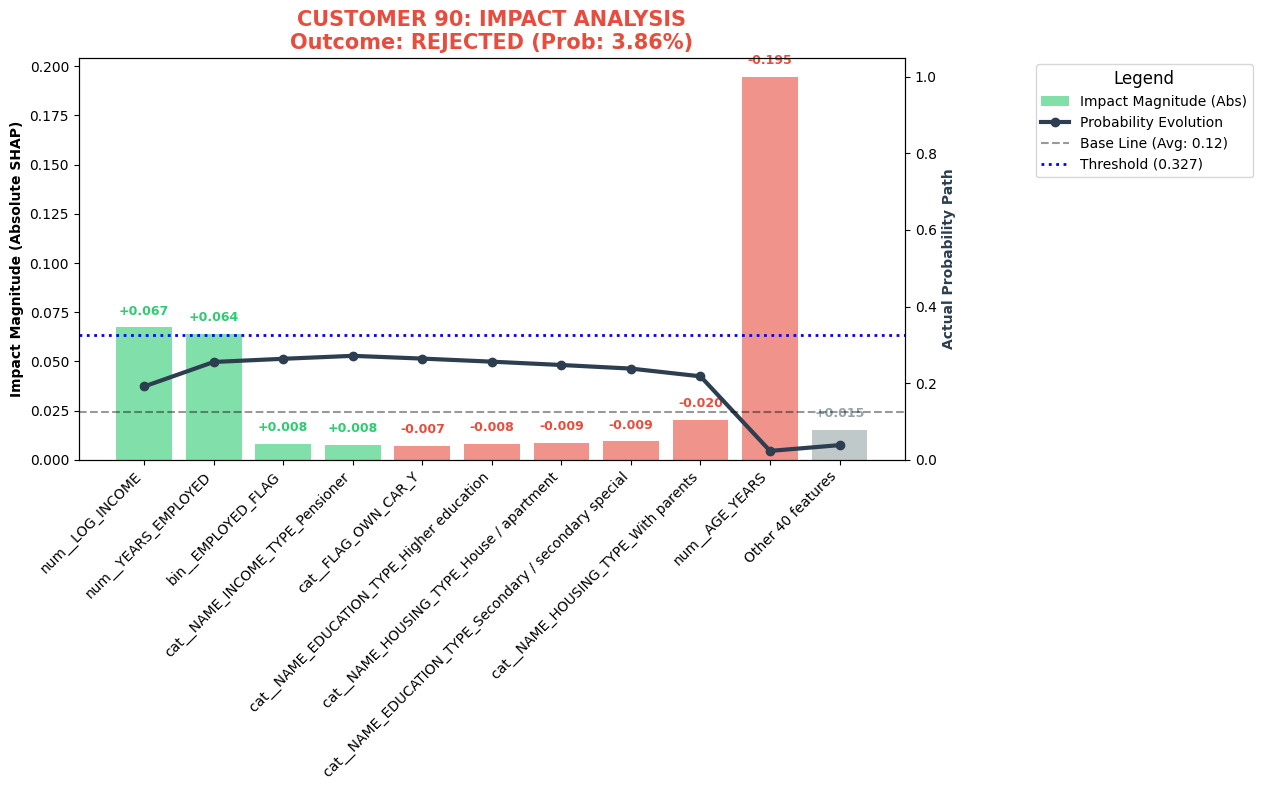


CUSTOMER 90
FINAL OUTCOME:      REJECTED
FINAL PROBABILITY:  3.86%
THRESHOLD:          32.73%
-----------------------------------------------------------------
TOP REASONS FOR REJECTION (ORIGINAL COLUMNS):
• DAYS_BIRTH: Penalty of -19.46%
• NAME_HOUSING_TYPE: Penalty of -2.87%
• NAME_EDUCATION_TYPE: Penalty of -1.72%

REAL value of the client: 0.0


In [91]:
print_result(explanation, best_threshold, 90, y_test)

## Conclusions

The project's goal was to develop a model capable of estimating customer creditworthiness and supporting the decision-making process for credit card issuance.

The final model selected, Random Forest, demonstrated high discriminative power, with a ROC-AUC close to 0.98 on both the training and test sets, indicating excellent generalization.

Optimizing the decision threshold allowed us to achieve a recall of 1.0 on the minority class, ensuring that all truly creditworthy customers are correctly identified.